# Validation to focus_metric and log_focus_score

1. Took one sharp image and mathematically blurred by exact, know amounts
2. Ran the processed images through the pipeline
3. Fit a curve - plotted "how blurry it really was" against "what the focus score said" (exponential decay)
4. Inverted the fit --> given a score, predict the blur amount
5. Ran the inverted formula on actual data

### Gaussian Blur
- Gaussian blur softens an image by mixing each pixel with its neighbors. The closer a neighboring pixel is, the more it influences the result; the father away, the less it matters. This mixing follows a shape of a bell cure (the Gaussian).

$$G_{\sigma}(x, y) = \frac{1}{2 \pi \sigma} \exp(- \frac{x^2 + y^2}{2 \sigma ^2})$$

where:
- $(x, y)$ is how far a neighboring pixel is from the center, in horizontal and vertical directions
- $\sigma$ is the "width" of the blur. Small $\sigma$ -> tight, narrow bell curve -> little blur; Large $\sigma$ -> wide, flat bell curve -> heavy blur

  Wrote sigma_00p0.jpg (sigma=0)
  Wrote sigma_00p5.jpg (sigma=0.5)
  Wrote sigma_01p0.jpg (sigma=1)
  Wrote sigma_02p0.jpg (sigma=2)
  Wrote sigma_03p0.jpg (sigma=3)
  Wrote sigma_04p0.jpg (sigma=4)
  Wrote sigma_06p0.jpg (sigma=6)
  Wrote sigma_08p0.jpg (sigma=8)
  Wrote sigma_12p0.jpg (sigma=12)
  Wrote sigma_16p0.jpg (sigma=16)

Manifest saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/data/blur_validation/manifest.csv
Results saved to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/blur_validation_results.csv

focus_metric monotonically decreasing with sigma: True


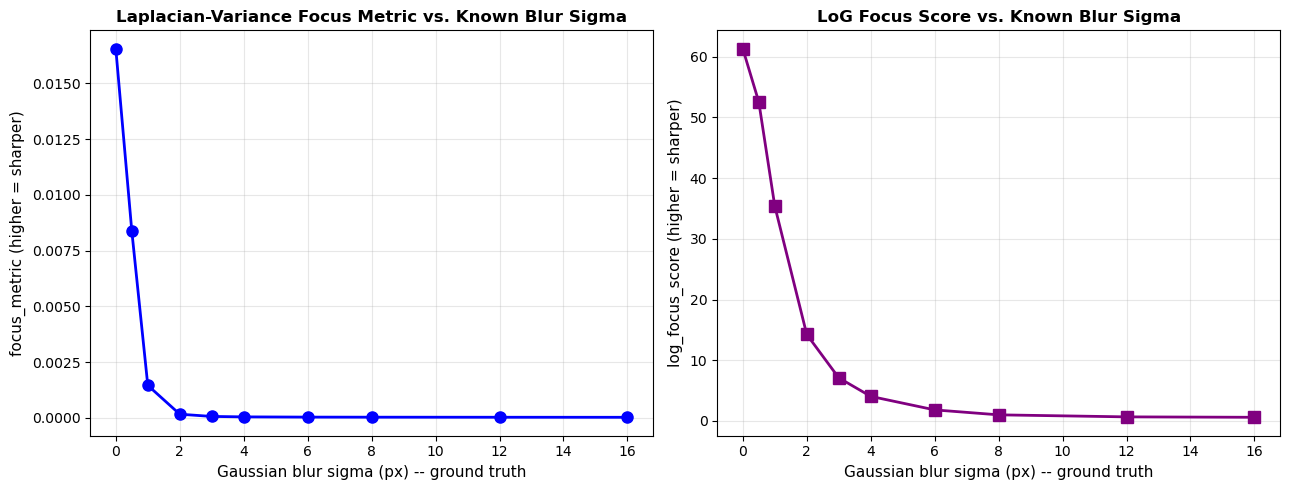

In [1]:
import sys
sys.path.insert(0, '../src')

from payload_analysis.validation import generate_blur_series, validate_focus_metrics, fit_focus_curve, plot_focus_curve_fit

from payload_analysis import (
    analyze_payload_image,
    analyze_payload_directory,
    compute_focus_scores,
    analyze_astigmatism_by_angle,
    plot_payload_metrics,
    plot_payload_metrics_timeline,
    plot_focus_scores,
    add_temperatures_and_plot,
    DATA_DIR,
    RESULTS_DIR
)

# source = DATA_DIR / 'New TRP' / 'TVACOFF_20260626-1236' / 'ALEASAT_capture_2026-06-26_123737.jpg'
source2 = DATA_DIR / 'New TRP' / 'test image' / '1600.BLUR.1.png'

# generate_blur_series(source, DATA_DIR / 'blur_validation')
generate_blur_series(source2, DATA_DIR / 'blur_validation')
results_df = validate_focus_metrics(DATA_DIR / 'blur_validation')

Fit for 'focus_metric': f(sigma) = 0.0169 * exp(-1.7216 * sigma) + -0.0001
  R^2 = 0.9849
Fit for 'log_focus_score': f(sigma) = 64.9995 * exp(-0.6504 * sigma) + -0.0604
  R^2 = 0.9865


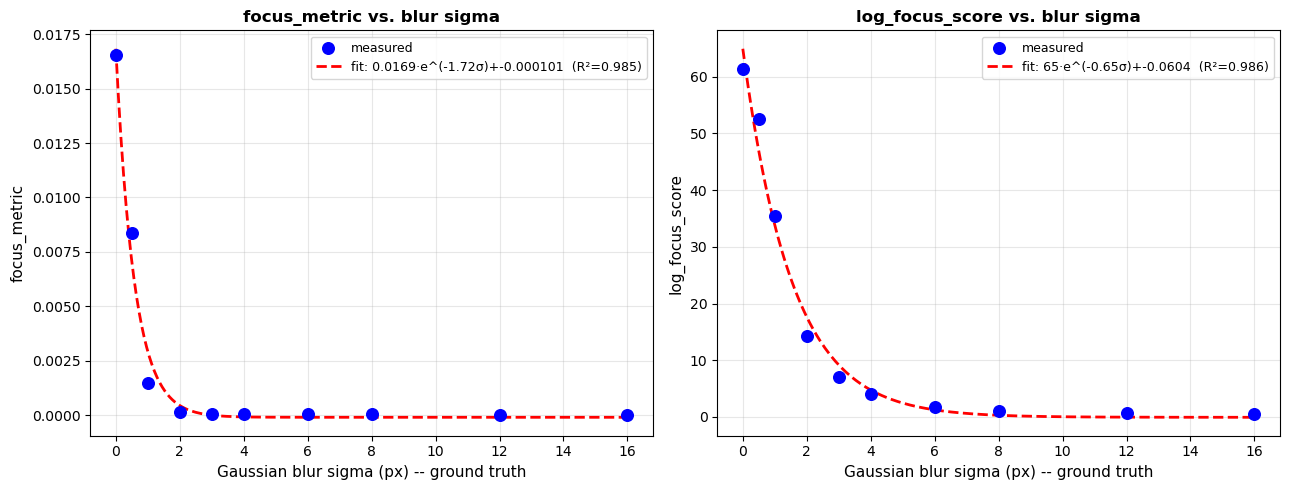

In [2]:

import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fit_focus = plot_focus_curve_fit(results_df, column='focus_metric', ax=axes[0])
fit_log = plot_focus_curve_fit(results_df, column='log_focus_score', ax=axes[1])
plt.tight_layout()
plt.show()

Saved sigma estimates to /Users/sharonchan/Downloads/aleasat-payload-analysis/results/New TRP_focus_scores_no_blur_with_sigma.csv


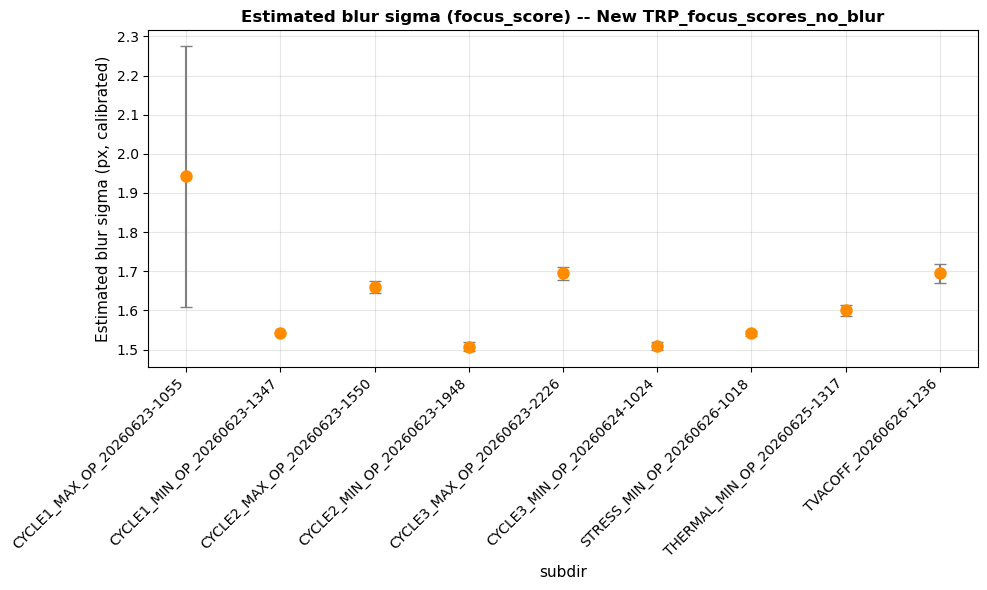

In [4]:
import pandas as pd
from payload_analysis import estimate_sigma_for_run
from payload_analysis.config import RESULTS_DIR

df = pd.read_csv(RESULTS_DIR / 'New TRP_focus_scores.csv')
df = df[df['subdir'] != 'blur']
filtered_path = RESULTS_DIR / 'New TRP_focus_scores_no_blur.csv'
df.to_csv(filtered_path, index=False)

trp_sigma_df = estimate_sigma_for_run(filtered_path, metric='focus_score', group_col='subdir')